# OTTO · From feature hypotheses to deployment decisions

**Alvaro Mendizabal | Research review | September 21, 2026 Pacific**

This notebook makes the latest research inspectable without AWS. It replays aggregate scoring evidence, not model training. The delivered 102-feature system scored **0.56842 private / 0.56862 public** after the competition deadline. The experiments below generally use a 134-feature pilot control; they do not establish an improvement over that submission.

**Question:** Which proposed capabilities survived a controlled comparison, and what should be stopped? We distinguish an exploratory effect, later evaluation, candidate coverage, achieved ranking quality and an execution failure. [Provenance, implementation and reproduction scope](README.md).

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "research/frontier/evidence.json").exists())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from research.frontier.review import read_evidence, primary_rows, coverage_rows, contribution_rows, show_chart

evidence = read_evidence(root / "research/frontier/evidence.json")
for study in evidence["studies"]:
    b = study["metrics"][study["baseline"]]["weighted_recall_at_20"]
    c = study["metrics"][study["challenger"]]["weighted_recall_at_20"]
    print(f'{study["title"]:26s} {study["sessions"]:5d} sessions | {b:.6f} -> {c:.6f} | {study["decision"]}')

Timing × training           2048 sessions | 0.569231 -> 0.578339 | PROMISING_BUT_INCONCLUSIVE
Later timing hybrid         8192 sessions | 0.550526 -> 0.550822 | UNSTABLE_NO_PROMOTION
Two-hop retrieval           8192 sessions | 0.557030 -> 0.552893 | COVERAGE_GAIN_REQUIRES_CANDIDATE_AWARE_TRAINING
Candidate-aware ranking     8192 sessions | 0.569467 -> 0.556037 | REJECT_PRIMARY_CANDIDATE_AWARE_RECIPE
Latent graph affinity       8192 sessions | 0.549031 -> 0.548528 | REJECT_THIS_LATENT_REPRESENTATION


## 1. Compare matched effects, not a cross-cohort leaderboard

The metric pools hits and capped denominators for each objective, weighted 0.1/0.3/0.6. Missing retrieval targets remain in the denominator. Every point score above is recalculated from integer aggregate counts.

Intervals below are the **reported paired session-bootstrap 95% intervals** from the returned studies. Public totals reproduce the point estimates, not the bootstrap samples. These intervals are descriptive: they do not correct for adaptive hypothesis search or training-seed variability. Each row has its own cohort and baseline; this is not a learning curve.

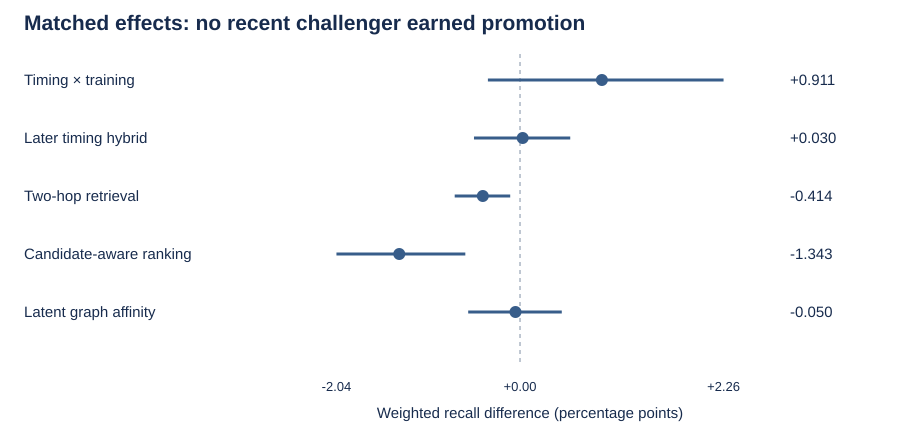

In [2]:
show_chart("Matched effects: no recent challenger earned promotion", primary_rows(evidence))

The exploratory timing × training result suggested an interaction, but the frozen later hybrid did not confirm a material gain. Both two-hop ranking recipes regressed. The latent-affinity effect was small and uncertain. Negative findings remain visible rather than being removed from the record.

## 2. Why better coverage was not enough

The two-hop experiment uses three row-normalized paths: time→time, time→cart, cart→order. It keeps the original 400-candidate budget and preserves previously observed items admitted by the original generator. This synthetic example executes the same propagation kernel; its IDs are invented and are not competition data.

In [3]:
import numpy as np
from scipy.sparse import csr_matrix
from research.frontier.retrieval import weighted_step

graph = csr_matrix(([2.0, 1.0], ([0, 1], [1, 2])), shape=(4, 4))
bridge, mass = weighted_step(graph, np.array([0]), np.array([1.0]))
items, score = weighted_step(graph, bridge, mass)
assert items.tolist() == [2] and np.allclose(score, [1.0])
print("Synthetic replay: observed 0 -> intermediate 1 -> retrieved 2; normalized path mass 1.0")

Synthetic replay: observed 0 -> intermediate 1 -> retrieved 2; normalized path mass 1.0


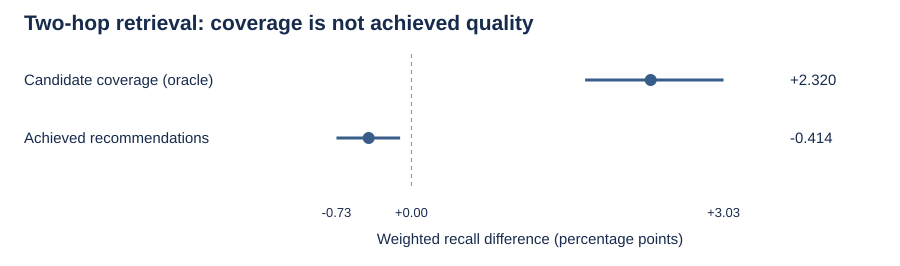

In [4]:
show_chart("Two-hop retrieval: coverage is not achieved quality", coverage_rows(evidence))

On 8,192 matched sessions, two-hop retrieval added **374 click, 78 cart and 20 order targets** to coverage. Yet the unchanged rankers selected **16 fewer click, 14 fewer cart and five fewer order targets** in their top 20. The next candidate-aware retraining study also regressed, including with 18 explicit path features.

**Decision:** stop that candidate-replacement recipe. The evidence supports a retrieval/ranking mismatch diagnosis, not a promise that retraining must solve it. Coverage is an oracle ceiling, not a model score.

## 3. Learned affinity: orders outweigh smaller gains elsewhere

The independent graph representation factors a normalized log-weight time graph into 64 dimensions and adds 16 candidate/session affinity summaries. It is not Word2Vec, ALS or NetMF. Candidate pools and 498,404 training rows were held fixed in the latent comparison. Positive click/cart movements were outweighed by seven lost order hits.

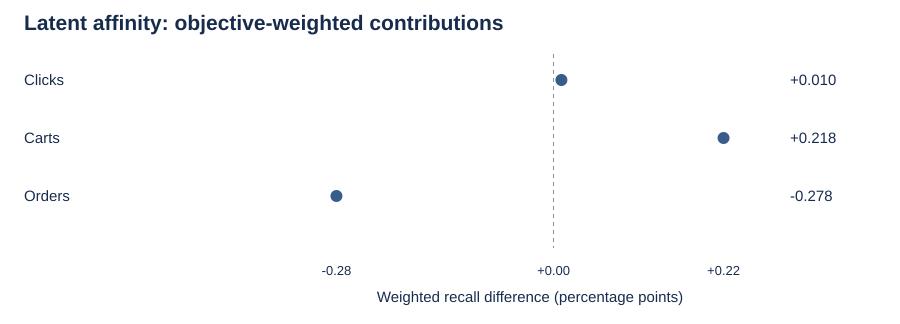

In [5]:
show_chart("Latent affinity: objective-weighted contributions", contribution_rows(evidence))

## 4. Execution failure is not a negative model result

The attempted 8,192→32,768 training comparison retained the original candidate policy, 134 features and model recipe. Its first execution verified 498,404 existing rows but stopped **before new fitting**: a caller omitted the external-candidate adapter and output path required by the real replay function. A permissive test double had hidden the integration error.

The correction passes the complete resource tuple to the real replay and removes the synthetic success receipt. A signature-enforcing regression fails before correction and all 47 handoff tests pass afterward. The AWS rerun is pending. No scale-up score can be inferred from successful engineering tests.

In [6]:
latest = evidence["latest_attempt"]
assert latest["new_models"] == 0 and latest["new_score"] is None
print(latest["status"])
print("New fitted models:", latest["new_models"])
print("Verified previous training rows:", latest["prior_training_rows_verified"])
print("Kaggle history refresh:", latest["kaggle_history_refresh"])
print("Repair:", latest["repair_status"])

BLOCKED_BEFORE_NEW_FITTING
New fitted models: 0
Verified previous training rows: 498404
Kaggle history refresh: AUTHENTICATION_REQUIRED
Repair: Call corrected locally; signature-enforcing test fails before and passes after. AWS rerun pending.


## 5. Decision and boundaries

The next experiment tests training support, not another feature block. It preserves the 8,192-session control, adds 24,576 fitting sessions, freezes a separate 16,384-session evaluation sample, and allows three new models. Require a gain of at least 0.003, nonnegative time-half gains, no pooled order loss, adequate order support and a positive lower paired interval before advancement.

Even a pass is relative to the pilot. A representative matched comparison with the actual submitted 102-feature pipeline and validated full official-prefix inference remain prerequisites to a new competition claim. This corpus has been explored before; no pristine holdout or winner reproduction is claimed.

**Public:** this executed review, aggregate counts, reported intervals, selected method code and provenance. **Private in AWS:** raw events, labels, session-level predictions, cohort IDs, full models, embeddings and environments. Publication does not migrate or reset the runtime. The latest successful authenticated submission history is from the earlier latent run; the scale attempt required authentication.

**Review completion:** the following sentinel proves that execution continued beyond every Plotly output. Saved SVG fallbacks and Plotly MIME payloads are retained inline.

In [7]:
print("FRONTIER_REVIEW_COMPLETE | 5 scoring studies | scale-up pending | no new submission")

FRONTIER_REVIEW_COMPLETE | 5 scoring studies | scale-up pending | no new submission
